# INN Hotels — Predicting Booking Cancellations

**Business context.** INN Hotels Group runs hotels in Portugal. Many bookings are cancelled, often late. That leaves
rooms empty, forces last-minute discounting and costs money on distribution and staffing. The hotel wants to **know
in advance which bookings are likely to be cancelled**, **understand why**, and **turn that into policies**.

**Objective.** Use the booking data to (1) find what drives cancellations, (2) build a model that predicts them,
and (3) recommend actions.

**How to read this notebook.** Every section starts with three lines:

- 🔍 **What we found**: the evidence that led to this step
- 💡 **Why it matters**: why that evidence changes what we do
- 🎯 **What we're doing now**: the action, and what it achieves

Every *Observations* block is **printed by code from the actual numbers**, so the text can never contradict the output.

| Column | Meaning |
|---|---|
| `Booking_ID` | unique booking identifier |
| `no_of_adults`, `no_of_children` | guests on the booking |
| `no_of_weekend_nights`, `no_of_week_nights` | nights booked (Sat/Sun vs Mon–Fri) |
| `type_of_meal_plan` | meal plan chosen |
| `required_car_parking_space` | 1 = parking needed |
| `room_type_reserved` | room type (encoded by the hotel) |
| `lead_time` | days between booking and arrival |
| `arrival_year`, `arrival_month`, `arrival_date` | arrival date, split in three |
| `market_segment_type` | where the booking came from |
| `repeated_guest` | 1 = has stayed before |
| `no_of_previous_cancellations`, `no_of_previous_bookings_not_canceled` | the guest's history |
| `avg_price_per_room` | average price per night (€) |
| `no_of_special_requests` | e.g. high floor, view, extra bed |
| `booking_status` | **target**: Canceled / Not_Canceled |

In [1]:
import calendar
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import Markdown, display
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 1  # same seed as the original analysis, so results are comparable
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid")
BLUE, RED, GREY = "#2a6fdb", "#d1495b", "#8c8c8c"
MONTH = dict(enumerate(calendar.month_name))  # 1 -> "January"
warnings.filterwarnings("ignore")  # after the imports: statsmodels re-enables its own warnings when imported


def say(text):
    """Show an observation as formatted text. The numbers come from the data, so text and output always agree."""
    display(Markdown(text))

In [2]:
raw = pd.read_csv("INNHotelsGroup.csv")
print(f"{raw.shape[0]:,} bookings x {raw.shape[1]} columns")
raw.head()

36,275 bookings x 19 columns


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.000,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.680,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.000,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.000,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.500,0,Canceled


## 1. Data overview

🔍 **What we found:** One row per booking, mixing numbers (lead time, price) and categories (meal plan, segment).  
💡 **Why it matters:** Before cleaning or modelling we need to know the types, the gaps and any hidden quality problems.  
🎯 **What we're doing now:** We list every column's type, number of distinct values and missing values. We also check for duplicates and impossible dates.

In [3]:
overview = pd.DataFrame({
    "type": raw.dtypes.astype(str),
    "distinct values": raw.nunique(),
    "missing": raw.isna().sum(),
})
display(overview)

exact_duplicates = raw.duplicated().sum()
lookalikes = raw.drop(columns="Booking_ID").duplicated().sum()  # identical apart from the ID

date_parts = raw[["arrival_year", "arrival_month", "arrival_date"]].set_axis(["year", "month", "day"], axis=1)
arrival = pd.to_datetime(date_parts, errors="coerce")
bad_dates = date_parts[arrival.isna()].value_counts()

say(f"""**Observations**
- No column has missing values. {raw.select_dtypes(exclude="number").shape[1]} columns are text (including the target).
- `Booking_ID` is unique for every row, so it is an identifier, not information. We drop it.
- Exact duplicate rows: **{exact_duplicates}**. That is only because the ID is unique: **ignoring the ID, {lookalikes:,} rows
  ({lookalikes / len(raw):.0%}) are identical to another booking**. They may be genuine (group or repeat bookings), so we keep them.
  But a test row with an identical twin in training is an easy question, so we will also score models on *unseen* rows.
- **{arrival.isna().sum()}** arrival dates don't exist: {", ".join(f"{d}/{m}/{y}" for (y, m, d) in bad_dates.index)} (2018 was not a leap year).
""")

,type,distinct values,missing
Booking_ID,str,36275,0
no_of_adults,int64,5,0
no_of_children,int64,6,0
no_of_weekend_nights,int64,8,0
no_of_week_nights,int64,18,0
type_of_meal_plan,str,4,0
required_car_parking_space,int64,2,0
room_type_reserved,str,7,0
lead_time,int64,352,0
arrival_year,int64,2,0


**Observations**
- No column has missing values. 5 columns are text (including the target).
- `Booking_ID` is unique for every row, so it is an identifier, not information. We drop it.
- Exact duplicate rows: **0**. That is only because the ID is unique: **ignoring the ID, 10,275 rows
  (28%) are identical to another booking**. They may be genuine (group or repeat bookings), so we keep them.
  But a test row with an identical twin in training is an easy question, so we will also score models on *unseen* rows.
- **37** arrival dates don't exist: 29/2/2018 (2018 was not a leap year).


## 2. Data cleaning

🔍 **What we found:** A handful of values are clearly wrong: 9-10 children on one booking, a room price over €500, and 29 February 2018.  
💡 **Why it matters:** Extreme typos distort averages and plots, and impossible dates break date calculations.  
🎯 **What we're doing now:** We fix only what is clearly an error, and record every change. We work on a copy, so `raw` stays untouched.

In [4]:
df = raw.drop(columns="Booking_ID").copy()

# 1) children: a few bookings list 9-10 children, almost certainly typos -> cap at 3
n_many_children = (df["no_of_children"] > 3).sum()
df["no_of_children"] = df["no_of_children"].clip(upper=3)

# 2) price: one room costs > EUR 500 (about 5x the median) -> cap it at the box-plot upper whisker
q1, q3 = df["avg_price_per_room"].quantile([0.25, 0.75])
upper_whisker = q3 + 1.5 * (q3 - q1)
n_price_outliers = (df["avg_price_per_room"] > 500).sum()
df.loc[df["avg_price_per_room"] > 500, "avg_price_per_room"] = upper_whisker

# 3) impossible dates (29 Feb 2018) -> move one day back, then derive the weekday
day = df["arrival_date"].where(arrival.notna(), df["arrival_date"] - 1)
arrival_fixed = pd.to_datetime(pd.DataFrame({"year": df["arrival_year"], "month": df["arrival_month"], "day": day}))
df["arrival_weekday"] = arrival_fixed.dt.dayofweek  # 0 = Monday ... 6 = Sunday

# 4) target as 0/1, so "the mean of booking_status" is simply the cancellation rate
df["booking_status"] = (df["booking_status"] == "Canceled").astype(int)

free = df[df["avg_price_per_room"] == 0]["market_segment_type"].value_counts()
say(f"""**Observations**
- Capped **{n_many_children}** bookings with more than 3 children, and **{n_price_outliers}** price above €500 (set to €{upper_whisker:.2f}).
- Moved **{arrival.isna().sum()}** impossible dates back one day, and added `arrival_weekday`.
- **{len(free)} segments** have rooms at €0: {", ".join(f"{s} ({n})" for s, n in free.items())}. Complimentary stays are free by
  design, so these prices are real and we keep them.
- The target is now 1 = Canceled, 0 = Not canceled.
""")

**Observations**
- Capped **3** bookings with more than 3 children, and **1** price above €500 (set to €179.55).
- Moved **37** impossible dates back one day, and added `arrival_weekday`.
- **2 segments** have rooms at €0: Complementary (354), Online (191). Complimentary stays are free by
  design, so these prices are real and we keep them.
- The target is now 1 = Canceled, 0 = Not canceled.


## 3. Exploratory analysis: one column at a time

🔍 **What we found:** We know the columns are clean, but not yet what typical bookings look like.  
💡 **Why it matters:** Distributions show skew, outliers and rare categories, which affect how we model and what we recommend.  
🎯 **What we're doing now:** We plot the two continuous columns in detail and every other column as a percentage bar chart.

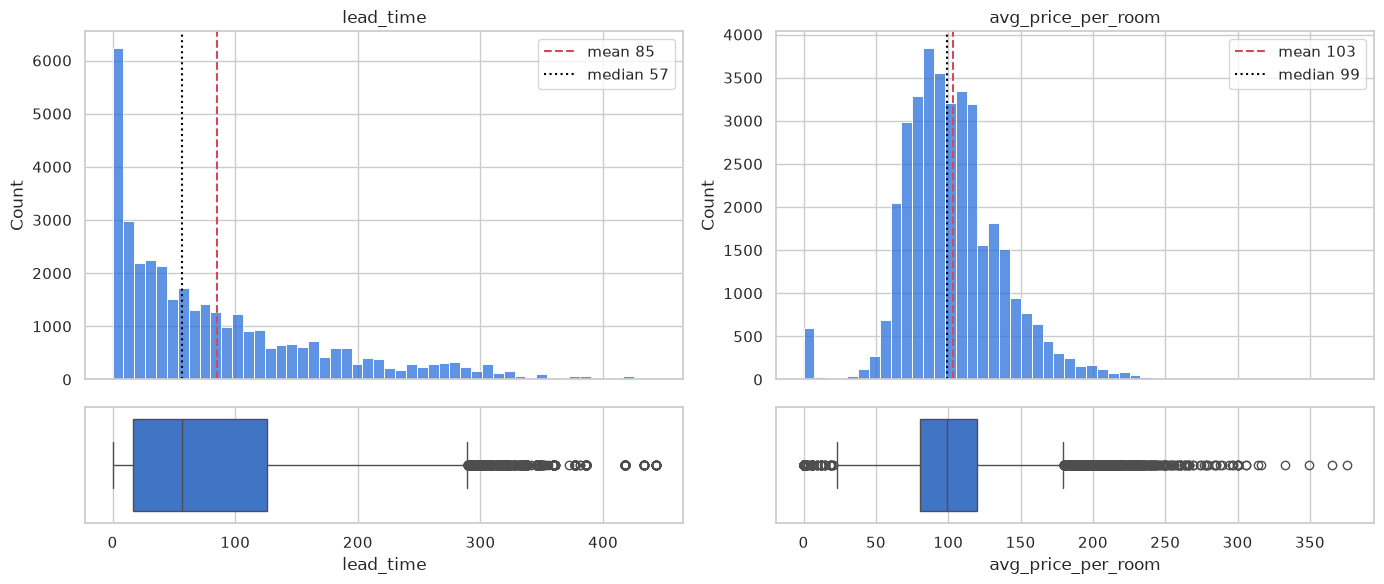

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), gridspec_kw={"height_ratios": [3, 1]}, sharex="col")
for i, col in enumerate(["lead_time", "avg_price_per_room"]):
    sns.histplot(df[col], bins=50, ax=axes[0, i], color=BLUE)
    axes[0, i].axvline(df[col].mean(), color=RED, ls="--", label=f"mean {df[col].mean():.0f}")
    axes[0, i].axvline(df[col].median(), color="black", ls=":", label=f"median {df[col].median():.0f}")
    axes[0, i].set_title(col); axes[0, i].legend()
    sns.boxplot(x=df[col], ax=axes[1, i], color=BLUE)
plt.tight_layout(); plt.show()

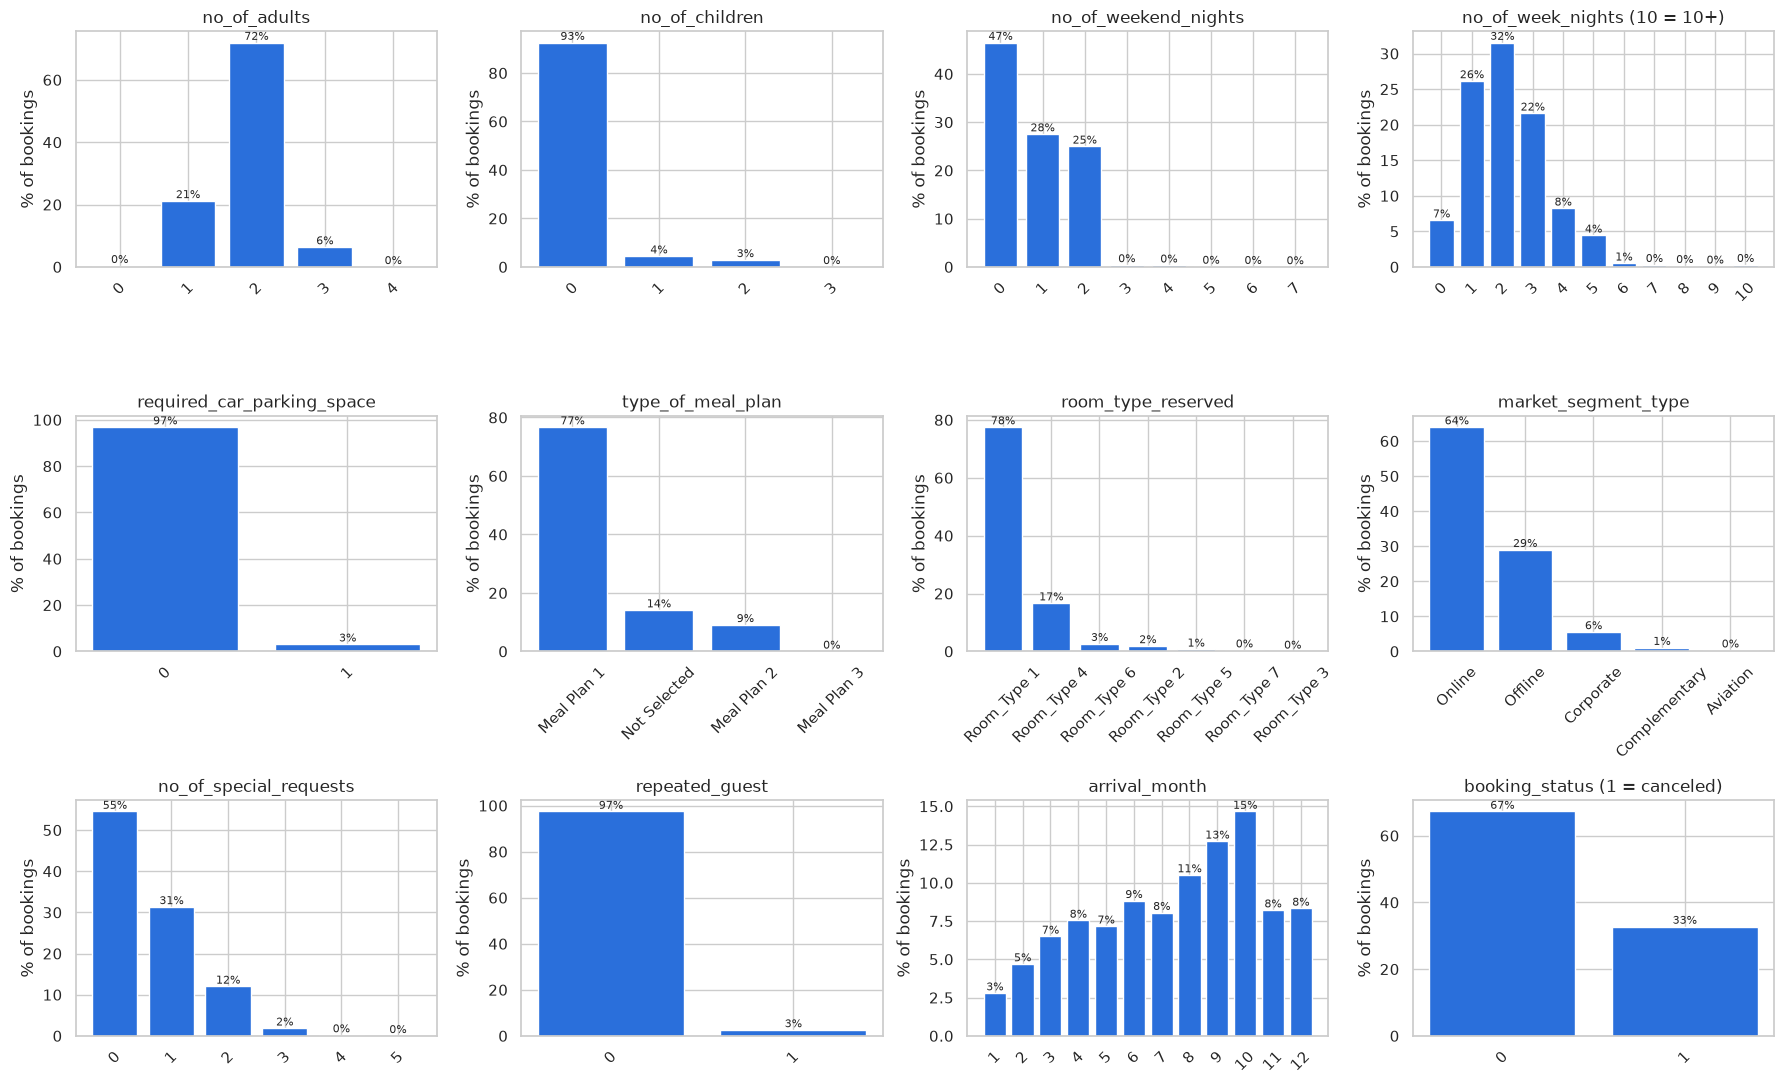

In [6]:
def pct_bar(series, ax, title):
    share = series.value_counts(normalize=True)
    share = share.sort_index() if pd.api.types.is_numeric_dtype(series) else share
    ax.bar(share.index.astype(str), share.values * 100, color=BLUE)
    for x, v in zip(share.index.astype(str), share.values * 100):
        ax.text(x, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=8)
    ax.set_title(title); ax.set_ylabel("% of bookings"); ax.tick_params(axis="x", labelrotation=45)

columns = {
    "no_of_adults": df["no_of_adults"], "no_of_children": df["no_of_children"],
    "no_of_weekend_nights": df["no_of_weekend_nights"],
    "no_of_week_nights (10 = 10+)": df["no_of_week_nights"].clip(upper=10),
    "required_car_parking_space": df["required_car_parking_space"], "type_of_meal_plan": df["type_of_meal_plan"],
    "room_type_reserved": df["room_type_reserved"], "market_segment_type": df["market_segment_type"],
    "no_of_special_requests": df["no_of_special_requests"], "repeated_guest": df["repeated_guest"],
    "arrival_month": df["arrival_month"], "booking_status (1 = canceled)": df["booking_status"],
}
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, (title, series) in zip(axes.ravel(), columns.items()):
    pct_bar(series, ax, title)
plt.tight_layout(); plt.show()

In [7]:
share = lambda col, value: (df[col] == value).mean()
nights = df["no_of_week_nights"].value_counts(normalize=True).head(3)
month_share = df["arrival_month"].value_counts(normalize=True)
segments = df["market_segment_type"].value_counts(normalize=True)
say(f"""**Observations**
- **Lead time** is right-skewed: median {df.lead_time.median():.0f} days, mean {df.lead_time.mean():.0f}, max {df.lead_time.max()}.
  A few bookings are made more than a year ahead.
- **Price**: median €{df.avg_price_per_room.median():.0f} per night; the €0 stays are the complimentary rooms.
- **{share('no_of_adults', 2):.0%}** of bookings are for 2 adults, and **{share('no_of_children', 0):.0%}** have no children.
- The most common week-night counts are {", ".join(f"{n} ({p:.0%})" for n, p in nights.items())}.
  **{share('no_of_weekend_nights', 0):.0%}** of bookings include no weekend night.
- **{share('required_car_parking_space', 0):.0%}** need no parking. Meal Plan 1 covers **{share('type_of_meal_plan', 'Meal Plan 1'):.0%}**
  and Room Type 1 covers **{share('room_type_reserved', 'Room_Type 1'):.0%}**.
- Market segments: {", ".join(f"{s} {p:.1%}" for s, p in segments.items())}.
- **{share('no_of_special_requests', 0):.0%}** make no special request, and only **{share('repeated_guest', 1):.1%}** are repeat guests.
- The busiest arrival month is **{MONTH[month_share.idxmax()]}** ({month_share.max():.1%} of bookings).
- **{df.booking_status.mean():.1%} of all bookings are cancelled**: about one in three rooms booked is at risk.
""")

**Observations**
- **Lead time** is right-skewed: median 57 days, mean 85, max 443.
  A few bookings are made more than a year ahead.
- **Price**: median €99 per night; the €0 stays are the complimentary rooms.
- **72%** of bookings are for 2 adults, and **93%** have no children.
- The most common week-night counts are 2 (32%), 1 (26%), 3 (22%).
  **47%** of bookings include no weekend night.
- **97%** need no parking. Meal Plan 1 covers **77%**
  and Room Type 1 covers **78%**.
- Market segments: Online 64.0%, Offline 29.0%, Corporate 5.6%, Complementary 1.1%, Aviation 0.3%.
- **55%** make no special request, and only **2.6%** are repeat guests.
- The busiest arrival month is **October** (14.7% of bookings).
- **32.8% of all bookings are cancelled**: about one in three rooms booked is at risk.


## 4. What drives cancellations?

🔍 **What we found:** One in three bookings is cancelled, but we don't yet know which kinds of booking.  
💡 **Why it matters:** Cancellation rates by group are the most actionable output of the whole project. They also show what a model should be able to learn.  
🎯 **What we're doing now:** We compute the cancellation rate for every group of every important column, and compare it with the overall rate (the dashed line).

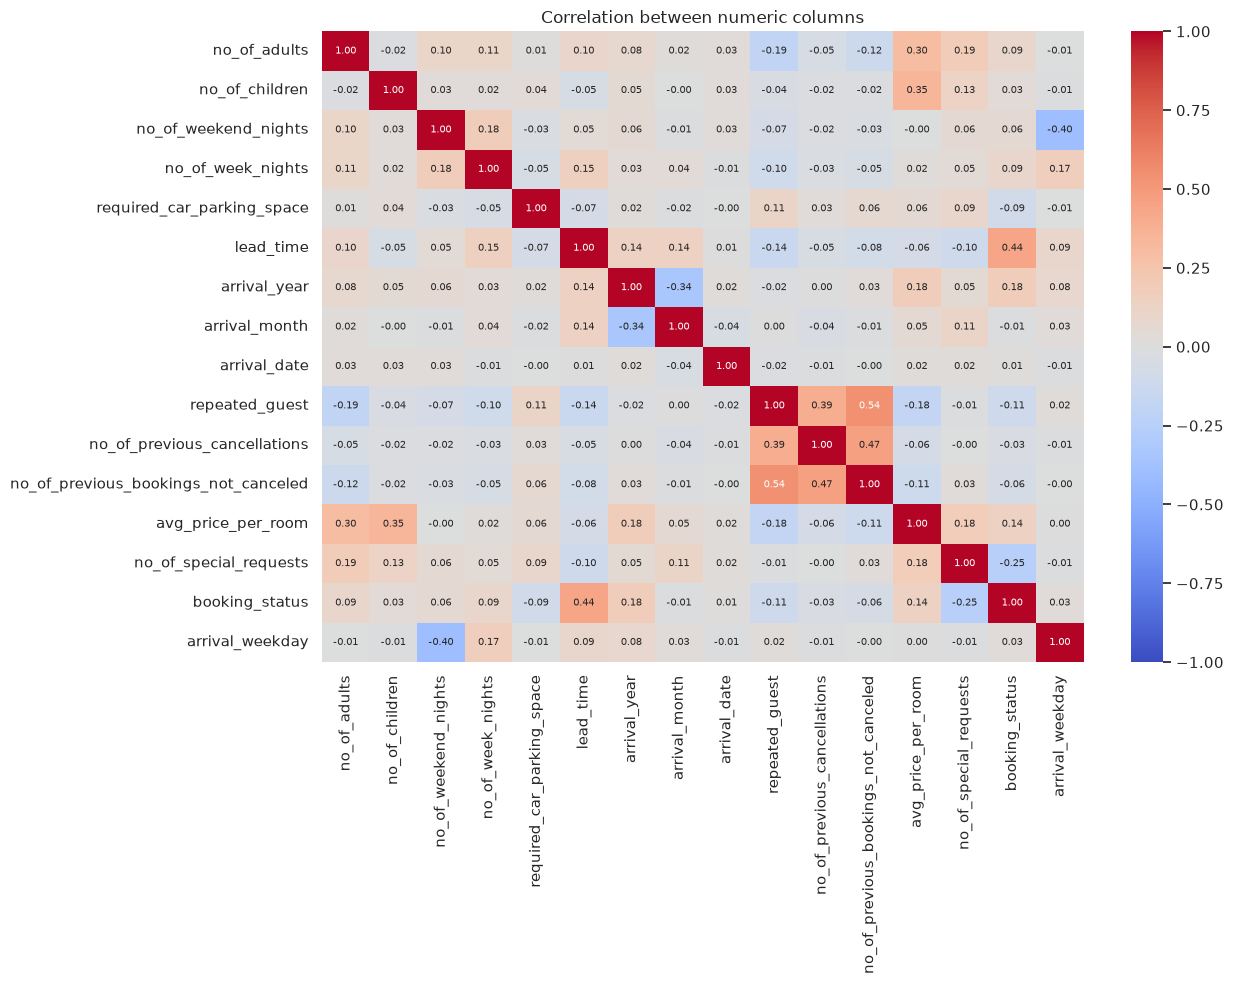

Correlation with booking_status (1 = canceled):
lead_time                               0.439
arrival_year                            0.180
avg_price_per_room                      0.142
no_of_week_nights                       0.093
no_of_adults                            0.087
no_of_weekend_nights                    0.062
no_of_children                          0.034
arrival_weekday                         0.030
arrival_date                            0.011
arrival_month                          -0.011
no_of_previous_cancellations           -0.034
no_of_previous_bookings_not_canceled   -0.060
required_car_parking_space             -0.086
repeated_guest                         -0.107
no_of_special_requests                 -0.253


In [8]:
num_cols = df.select_dtypes("number").columns
corr = df[num_cols].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("Correlation between numeric columns"); plt.tight_layout(); plt.show()
print("Correlation with booking_status (1 = canceled):")
print(corr["booking_status"].drop("booking_status").sort_values(ascending=False).round(3).to_string())

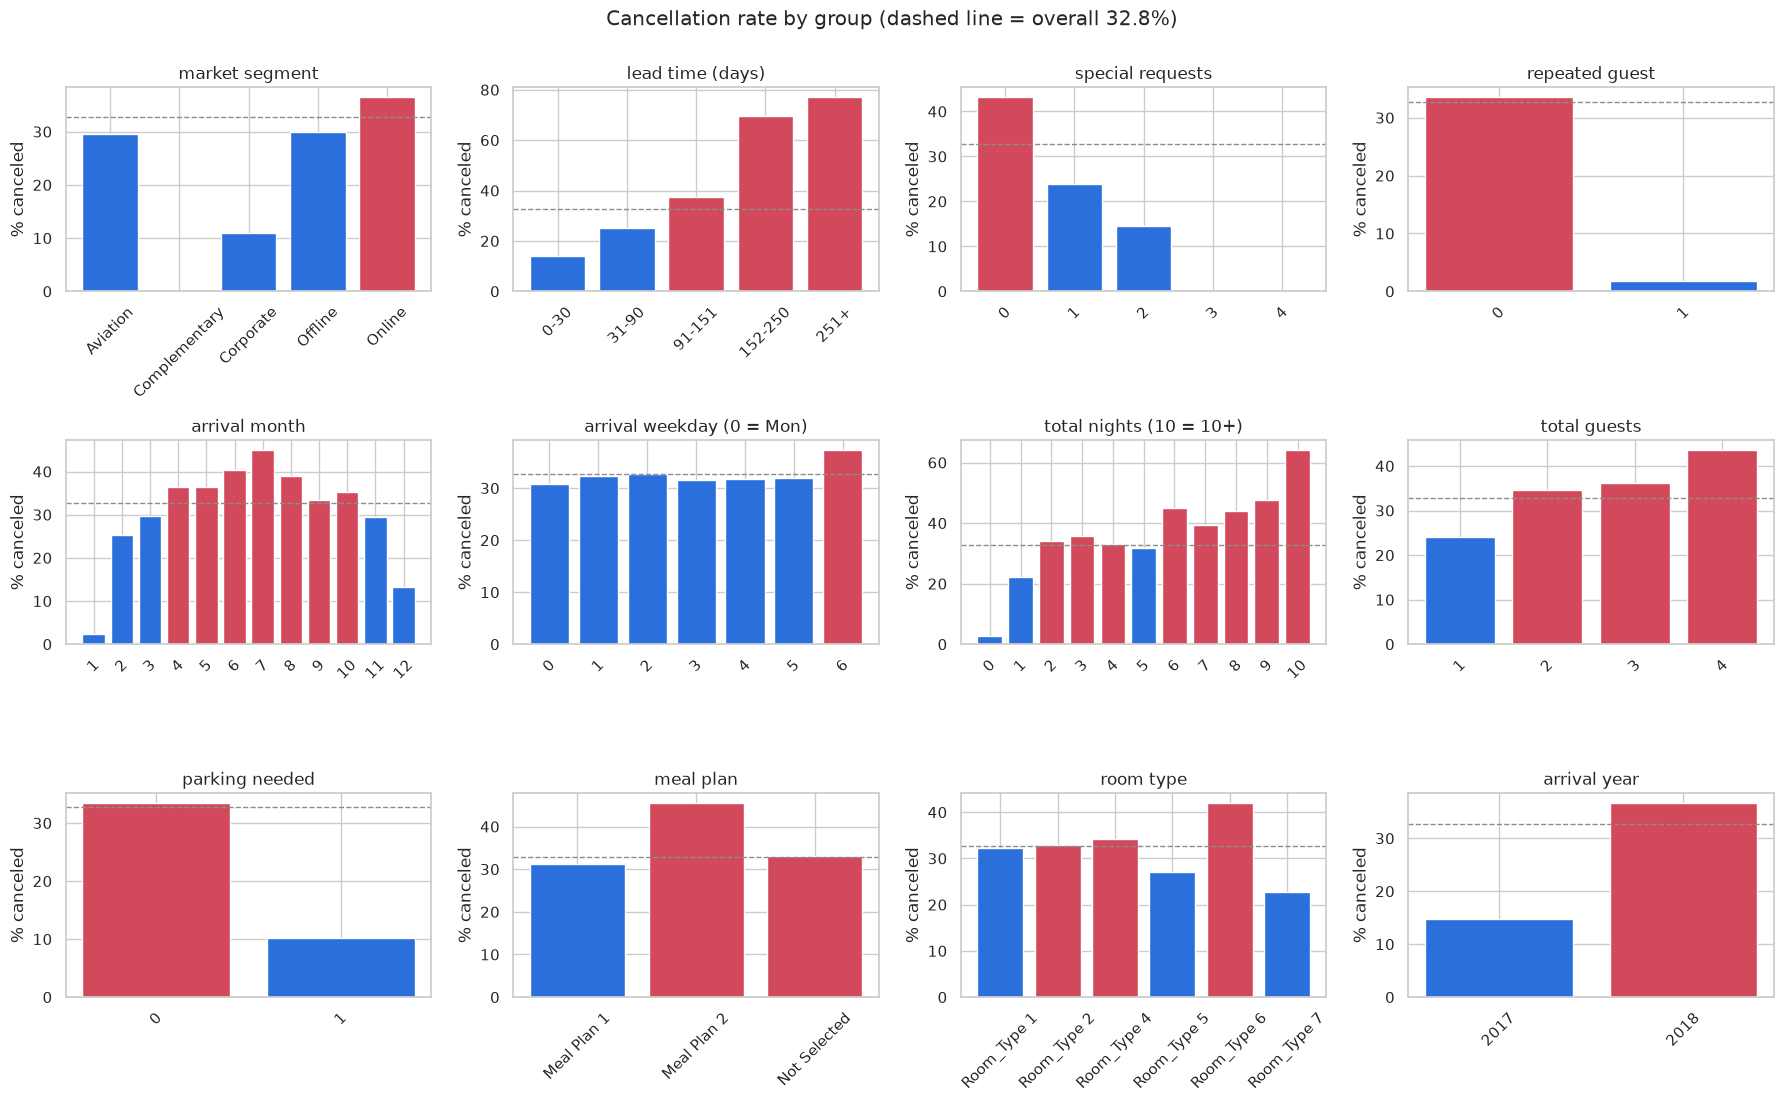

In [9]:
overall = df["booking_status"].mean()
df["total_nights"] = df["no_of_week_nights"] + df["no_of_weekend_nights"]
df["total_guests"] = df["no_of_adults"] + df["no_of_children"]
lead_band = pd.cut(df["lead_time"], [-1, 30, 90, 151, 250, 500], labels=["0-30", "31-90", "91-151", "152-250", "251+"])


def cancel_rate(key, min_rows=30):
    """Cancellation rate and number of bookings per group (groups with fewer than `min_rows` bookings are hidden)."""
    table = df["booking_status"].groupby(key, observed=True).agg(rate="mean", bookings="size")
    return table[table["bookings"] >= min_rows]


drivers = {
    "market segment": cancel_rate(df["market_segment_type"]),
    "lead time (days)": cancel_rate(lead_band),
    "special requests": cancel_rate(df["no_of_special_requests"]),
    "repeated guest": cancel_rate(df["repeated_guest"]),
    "arrival month": cancel_rate(df["arrival_month"]),
    "arrival weekday (0 = Mon)": cancel_rate(df["arrival_weekday"]),
    "total nights (10 = 10+)": cancel_rate(df["total_nights"].clip(upper=10)),
    "total guests": cancel_rate(df["total_guests"]),
    "parking needed": cancel_rate(df["required_car_parking_space"]),
    "meal plan": cancel_rate(df["type_of_meal_plan"]),
    "room type": cancel_rate(df["room_type_reserved"]),
    "arrival year": cancel_rate(df["arrival_year"]),
}
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, (title, table) in zip(axes.ravel(), drivers.items()):
    ax.bar(table.index.astype(str), table["rate"] * 100, color=[RED if r > overall else BLUE for r in table["rate"]])
    ax.axhline(overall * 100, color=GREY, ls="--", lw=1)
    ax.set_title(title); ax.set_ylabel("% canceled"); ax.tick_params(axis="x", labelrotation=45)
plt.suptitle(f"Cancellation rate by group (dashed line = overall {overall:.1%})", y=1.0)
plt.tight_layout(); plt.show()

In [10]:
rate = lambda name, group: drivers[name].loc[group, "rate"]
seg, lead, req, month = drivers["market segment"], drivers["lead time (days)"], drivers["special requests"], drivers["arrival month"]
nights = drivers["total nights (10 = 10+)"]
say(f"""**Observations** (overall cancellation rate {overall:.1%})
- **Lead time is the strongest driver.** {rate('lead time (days)', '0-30'):.0%} of bookings made within 30 days are cancelled,
  compared with **{rate('lead time (days)', '152-250'):.0%}** at 152-250 days and **{rate('lead time (days)', '251+'):.0%}** beyond 250 days.
- **Special requests signal commitment.** Bookings with no request cancel **{rate('special requests', 0):.0%}** of the time, with 1 request
  {rate('special requests', 1):.0%}, and with 2 requests {rate('special requests', 2):.0%}. With 3 or more, almost none cancel.
- **Segment**: Online **{rate('market segment', 'Online'):.1%}**, Offline {rate('market segment', 'Offline'):.1%},
  Aviation {rate('market segment', 'Aviation'):.1%}, Corporate {rate('market segment', 'Corporate'):.1%},
  Complementary **{rate('market segment', 'Complementary'):.1%}** (never cancelled).
- **Repeat guests** cancel only {rate('repeated guest', 1):.1%} of the time, against {rate('repeated guest', 0):.1%} for new guests.
- **Season**: cancellations are highest for {", ".join(f"{MONTH[m]} ({r:.0%})" for m, r in month["rate"].nlargest(3).items())}
  arrivals, and lowest for {", ".join(f"{MONTH[m]} ({r:.0%})" for m, r in month["rate"].nsmallest(2).items())}. Guests travelling
  for the holidays rarely change their plans.
- **Long stays** cancel more: {nights.loc[nights.index >= 6, "rate"].mean():.0%} on average for 6+ nights, against {rate('total nights (10 = 10+)', 1):.0%} for 1 night.
- Bookings that need **parking** cancel far less ({rate('parking needed', 1):.0%} vs {rate('parking needed', 0):.0%}).
- 2018 arrivals cancel more than 2017 arrivals ({rate('arrival year', 2018):.0%} vs {rate('arrival year', 2017):.0%}). The 2017 data
  only covers {MONTH[df.loc[df.arrival_year == 2017, "arrival_month"].min()]}-{MONTH[df.loc[df.arrival_year == 2017, "arrival_month"].max()]},
  so treat this year effect with care.
""")

**Observations** (overall cancellation rate 32.8%)
- **Lead time is the strongest driver.** 14% of bookings made within 30 days are cancelled,
  compared with **70%** at 152-250 days and **77%** beyond 250 days.
- **Special requests signal commitment.** Bookings with no request cancel **43%** of the time, with 1 request
  24%, and with 2 requests 15%. With 3 or more, almost none cancel.
- **Segment**: Online **36.5%**, Offline 29.9%,
  Aviation 29.6%, Corporate 10.9%,
  Complementary **0.0%** (never cancelled).
- **Repeat guests** cancel only 1.7% of the time, against 33.6% for new guests.
- **Season**: cancellations are highest for July (45%), June (40%), August (39%)
  arrivals, and lowest for January (2%), December (13%). Guests travelling
  for the holidays rarely change their plans.
- **Long stays** cancel more: 48% on average for 6+ nights, against 22% for 1 night.
- Bookings that need **parking** cancel far less (10% vs 33%).
- 2018 arrivals cancel more than 2017 arrivals (37% vs 15%). The 2017 data
  only covers July-December,
  so treat this year effect with care.


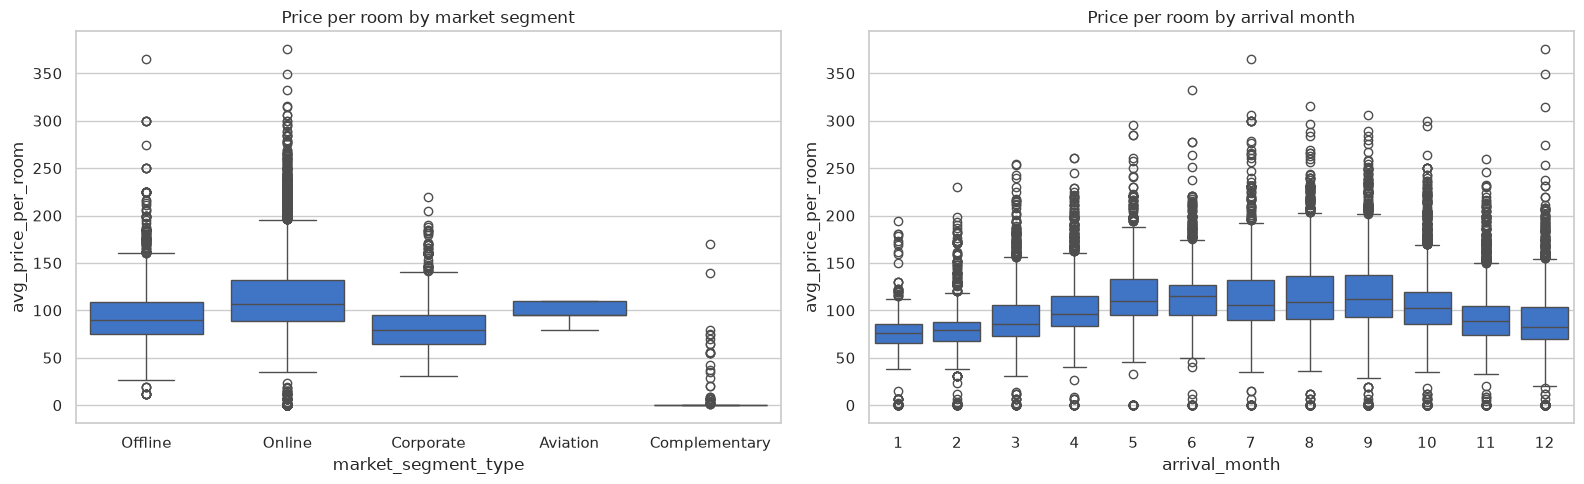

**Observations**
- Median price by segment: Online €107, Aviation €95, Offline €90, Corporate €79, Complementary €0. Online guests pay the most and also cancel the most.
- The most expensive arrival months are June, September, May, and the cheapest are December, February, January.
- Cancelled bookings were priced higher (median €108 vs €95).


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df, x="market_segment_type", y="avg_price_per_room", ax=axes[0], color=BLUE)
axes[0].set_title("Price per room by market segment")
sns.boxplot(data=df, x="arrival_month", y="avg_price_per_room", ax=axes[1], color=BLUE)
axes[1].set_title("Price per room by arrival month")
plt.tight_layout(); plt.show()

price_seg = df.groupby("market_segment_type")["avg_price_per_room"].median().sort_values(ascending=False)
price_month = df.groupby("arrival_month")["avg_price_per_room"].median().sort_values(ascending=False)
price_status = df.groupby("booking_status")["avg_price_per_room"].median()
say(f"""**Observations**
- Median price by segment: {", ".join(f"{s} €{p:.0f}" for s, p in price_seg.items())}. Online guests pay the most and also cancel the most.
- The most expensive arrival months are {", ".join(MONTH[m] for m in price_month.index[:3])}, and the cheapest are {", ".join(MONTH[m] for m in price_month.index[-3:])}.
- Cancelled bookings were priced higher (median €{price_status[1]:.0f} vs €{price_status[0]:.0f}).
""")

## 5. Features for modelling and multicollinearity

🔍 **What we found:** `total_nights` is *exactly* week nights + weekend nights, and `total_guests` is *exactly* adults + children.  
💡 **Why it matters:** Logistic regression can't separate a total from its parts. This made the earlier analysis show infinite VIF and fail to converge.  
🎯 **What we're doing now:** Tree models get both the totals and the parts. Logistic regression gets only the parts, and compares each category with the *most common* one (e.g. every segment vs Online), so the effects are easy to read. We check VIF to confirm the problem is gone.

In [12]:
categorical = ["type_of_meal_plan", "room_type_reserved", "market_segment_type"]
features = [c for c in df.columns if c != "booking_status"]
X_all = pd.get_dummies(df[features], columns=categorical, dtype=int)  # one 0/1 column per category
y = df["booking_status"]

# Logistic regression needs one "reference" category per column left out; we leave out the most common one.
reference = {col: df[col].mode()[0] for col in categorical}
tree_cols = list(X_all.columns)                                                          # trees: everything
linear_cols = [c for c in tree_cols if c not in ("total_nights", "total_guests")         # linear: parts only,
               and c not in {f"{col}_{ref}" for col, ref in reference.items()}]          # minus the references


def vif(cols):
    X = sm.add_constant(X_all[cols].astype(float))
    return pd.Series([variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])], index=cols)


vif_all = vif([c for c in tree_cols if c in df.columns])  # numeric columns incl. totals
vif_linear = vif(linear_cols)
print("Highest VIF with the totals included (one-hot columns left out here, to isolate the totals):")
print(vif_all.sort_values(ascending=False).head(6).map("{:,.0f}".format).to_string())
print("\nHighest VIF in the logistic-regression feature set:")
print(vif_linear.sort_values(ascending=False).head(6).round(2).to_string())
say(f"""**Observations**
- With the totals included, **{(vif_all > 1000).sum()} columns have VIF above 1,000** (effectively infinite): perfect collinearity.
  This is what broke the original logistic regression.
- In the logistic-regression set (reference categories: {", ".join(f"{c} = {r}" for c, r in reference.items())}) the largest VIF is
  **{vif_linear.max():.1f}** (`{vif_linear.idxmax()}`). {"Below 5 is considered safe, so the coefficients can be trusted." if vif_linear.max() < 5 else "That is above 5, so treat that coefficient with care."}
""")

Highest VIF with the totals included (one-hot columns left out here, to isolate the totals):
total_guests            1,000,799,917,193,444
no_of_children                      3,543,843
no_of_adults                        3,171,503
no_of_week_nights                   2,331,684
total_nights                          348,069
no_of_weekend_nights                  274,982

Highest VIF in the logistic-regression feature set:
no_of_children                         2.080
room_type_reserved_Room_Type 6         2.050
avg_price_per_room                     2.050
repeated_guest                         1.760
no_of_previous_bookings_not_canceled   1.610
market_segment_type_Offline            1.610


**Observations**
- With the totals included, **6 columns have VIF above 1,000** (effectively infinite): perfect collinearity.
  This is what broke the original logistic regression.
- In the logistic-regression set (reference categories: type_of_meal_plan = Meal Plan 1, room_type_reserved = Room_Type 1, market_segment_type = Online) the largest VIF is
  **2.1** (`no_of_children`). Below 5 is considered safe, so the coefficients can be trusted.


## 6. Train/test split, look-alike rows and a baseline

🔍 **What we found:** 28% of bookings have an identical twin. 67% of bookings are not cancelled.  
💡 **Why it matters:** Twins that land on both sides of the split make the test set easier than real new bookings. And a lazy model that predicts 'not cancelled' every time is already 67% accurate, so accuracy alone is misleading.  
🎯 **What we're doing now:** We hold out 30% of rows as a test set (stratified, same seed as before) and flag the test rows with no twin in training. **F1 for the Canceled class** is our main score; it rewards catching cancellations without too many false alarms.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

row_key = pd.util.hash_pandas_object(X_all, index=False)  # one fingerprint per set of booking details
unseen = ~row_key.loc[X_test.index].isin(set(row_key.loc[X_train.index])).to_numpy()

baseline_pred = np.zeros(len(y_test), dtype=int)  # "nobody cancels"
say(f"""**Observations**
- Training rows: **{len(X_train):,}**, test rows: **{len(X_test):,}**. The cancellation rate is {y_train.mean():.1%} in training and {y_test.mean():.1%} in test.
- **{(~unseen).mean():.0%} of test rows have an identical twin in training.** The remaining {unseen.mean():.0%} ("unseen rows") are
  the fairest test of how the model will do on genuinely new bookings.
- Baseline "nobody cancels": accuracy **{(baseline_pred == y_test).mean():.1%}**, but F1 for Canceled **{f1_score(y_test, baseline_pred):.2f}**.
  It never catches a single cancellation. Every model below must beat this.
""")

**Observations**
- Training rows: **25,392**, test rows: **10,883**. The cancellation rate is 32.8% in training and 32.8% in test.
- **33% of test rows have an identical twin in training.** The remaining 67% ("unseen rows") are
  the fairest test of how the model will do on genuinely new bookings.
- Baseline "nobody cancels": accuracy **67.2%**, but F1 for Canceled **0.00**.
  It never catches a single cancellation. Every model below must beat this.


In [14]:
results = []


def best_threshold(y_true, proba):
    """Threshold with the highest F1 for Canceled. Always chosen on TRAINING data, never on the test set."""
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    return float(thresholds[np.argmax(f1[:-1])])


def evaluate(name, model, cols, tune_threshold=True, plot=True):
    """Fit `model`, pick its threshold from out-of-fold predictions on the training set, score it once on the test set."""
    oof = cross_val_predict(model, X_train[cols], y_train, cv=CV, method="predict_proba", n_jobs=-1)[:, 1]
    threshold = best_threshold(y_train, oof) if tune_threshold else 0.5
    fitted = clone(model).fit(X_train[cols], y_train)
    p_train, p_test = fitted.predict_proba(X_train[cols])[:, 1], fitted.predict_proba(X_test[cols])[:, 1]
    pred_train, pred_test = p_train >= threshold, p_test >= threshold
    row = {
        "model": name, "threshold": threshold,
        "CV F1 (train folds)": f1_score(y_train, oof >= threshold),
        "train F1": f1_score(y_train, pred_train),
        "test precision": precision_score(y_test, pred_test), "test recall": recall_score(y_test, pred_test),
        "test F1": f1_score(y_test, pred_test), "test ROC-AUC": roc_auc_score(y_test, p_test),
        "test F1 (unseen rows)": f1_score(y_test[unseen], pred_test[unseen]),
    }
    results[:] = [r for r in results if r["model"] != name] + [row]
    print(pd.Series(row).drop("model").round(3).to_string())
    if plot:
        fig, ax = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay.from_predictions(y_test, pred_test, display_labels=["Not canceled", "Canceled"],
                                                cmap="Blues", colorbar=False, ax=ax)
        ax.set_title(f"{name}\n(test set, threshold {threshold:.2f})", fontsize=10)
        plt.tight_layout(); plt.show()
    return fitted

## 7. Logistic regression (statsmodels): the explainable model

🔍 **What we found:** Complementary bookings are *never* cancelled (0%).  
💡 **Why it matters:** When a group is always 0, logistic regression tries to push its coefficient to minus infinity ('perfect separation'). The fit then never converges and every p-value becomes unreliable. This was the second reason the original model failed to converge.  
🎯 **What we're doing now:** We show the failure, remove that one dummy (complimentary stays are handled by a simple rule: they don't cancel), then drop insignificant variables one at a time (p > 0.05) until the model is clean.

In [15]:
first = sm.Logit(y_train, sm.add_constant(X_train[linear_cols].astype(float))).fit(disp=False, maxiter=200)
print(f"All features    -> converged: {first.mle_retvals['converged']}, "
      f"Complementary coefficient = {first.params['market_segment_type_Complementary']:.1f} "
      f"(p = {first.pvalues['market_segment_type_Complementary']:.3f})")

lr_cols = [c for c in linear_cols if c != "market_segment_type_Complementary"]
dropped = []
while True:
    logit = sm.Logit(y_train, sm.add_constant(X_train[lr_cols].astype(float))).fit(disp=False, maxiter=200)
    pvalues = logit.pvalues.drop("const")
    if pvalues.max() <= 0.05:
        break
    worst = pvalues.idxmax()
    dropped.append(f"{worst} (p={pvalues.max():.2f})")
    lr_cols.remove(worst)

print(f"Final model     -> converged: {logit.mle_retvals['converged']}, {len(lr_cols)} features, pseudo R² = {logit.prsquared:.3f}")
print("Dropped as not significant:", ", ".join(dropped) or "none")
print(logit.summary2().tables[1][["Coef.", "P>|z|"]].round(3).to_string())

All features    -> converged: False, Complementary coefficient = -29.4 (p = 0.997)


Final model     -> converged: True, 19 features, pseudo R² = 0.331
Dropped as not significant: market_segment_type_Aviation (p=0.98), arrival_weekday (p=0.67), room_type_reserved_Room_Type 3 (p=0.64), no_of_adults (p=0.38), no_of_children (p=0.36), type_of_meal_plan_Meal Plan 3 (p=0.23), no_of_previous_bookings_not_canceled (p=0.13), arrival_date (p=0.12)
                                  Coef.  P>|z|
const                          -869.408  0.000
no_of_weekend_nights              0.150  0.000
no_of_week_nights                 0.036  0.003
required_car_parking_space       -1.615  0.000
lead_time                         0.016  0.000
arrival_year                      0.430  0.000
arrival_month                    -0.049  0.000
repeated_guest                   -3.074  0.000
no_of_previous_cancellations      0.289  0.000
avg_price_per_room                0.019  0.000
no_of_special_requests           -1.486  0.000
type_of_meal_plan_Meal Plan 2     0.166  0.013
type_of_meal_plan_Not Selected 

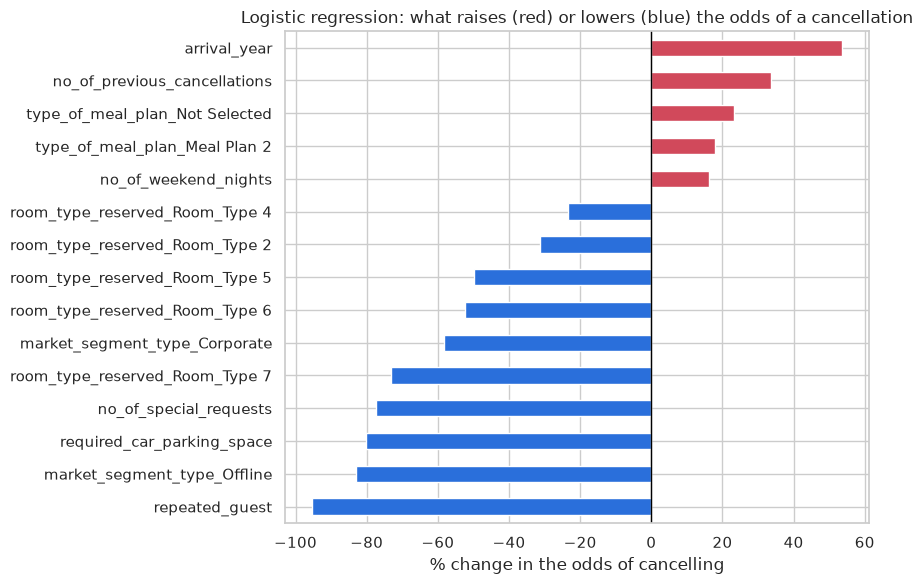

**Interpretation** (holding all other columns fixed)
- `no_of_special_requests`: each extra request → odds of cancelling **-77%**
- `required_car_parking_space`: yes vs no → odds of cancelling **-80%**
- `repeated_guest`: yes vs no → odds of cancelling **-95%**
- `lead_time`: 30 more days → odds of cancelling **+61%**
- `avg_price_per_room`: €10 more per night → odds of cancelling **+21%**
- `market_segment_type_Corporate`: vs Online bookings → odds of cancelling **-58%**
- `market_segment_type_Offline`: vs Online bookings → odds of cancelling **-83%**

In [16]:
odds = pd.DataFrame({"coefficient": logit.params.drop("const")})
odds["odds ratio"] = np.exp(odds["coefficient"])
odds["change in odds"] = (odds["odds ratio"] - 1) * 100
odds = odds.reindex(odds["coefficient"].abs().sort_values(ascending=False).index)

odds["change in odds"].head(15).sort_values().plot.barh(
    color=[RED if v > 0 else BLUE for v in odds["change in odds"].head(15).sort_values()], figsize=(9, 6))
plt.axvline(0, color="black", lw=1); plt.xlabel("% change in the odds of cancelling")
plt.title("Logistic regression: what raises (red) or lowers (blue) the odds of a cancellation")
plt.tight_layout(); plt.show()

per_unit = {"lead_time": 30, "avg_price_per_room": 10}  # express small per-unit effects on a readable scale
lines = []
for feat in ["no_of_special_requests", "required_car_parking_space", "repeated_guest", "lead_time", "avg_price_per_room",
             "market_segment_type_Corporate", "market_segment_type_Offline", "market_segment_type_Aviation"]:
    if feat in odds.index:
        step = per_unit.get(feat, 1)
        change = (np.exp(odds.loc[feat, "coefficient"] * step) - 1) * 100
        unit = f"{step} more days" if feat == "lead_time" else f"€{step} more per night" if feat == "avg_price_per_room" else \
               "each extra request" if feat == "no_of_special_requests" else f"vs {reference['market_segment_type']} bookings" if "_type_" in feat else "yes vs no"
        lines.append(f"- `{feat}`: {unit} → odds of cancelling **{change:+.0f}%**")
say("**Interpretation** (holding all other columns fixed)\n" + "\n".join(lines))

Logistic regression, default threshold 0.50


threshold               0.500
CV F1 (train folds)     0.682
train F1                0.682
test precision          0.733
test recall             0.626
test F1                 0.675
test ROC-AUC            0.861
test F1 (unseen rows)   0.623


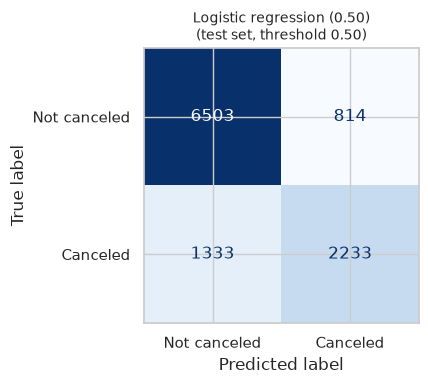


Logistic regression, threshold tuned on training folds


threshold               0.421
CV F1 (train folds)     0.700
train F1                0.699
test precision          0.690
test recall             0.694
test F1                 0.692
test ROC-AUC            0.861
test F1 (unseen rows)   0.642


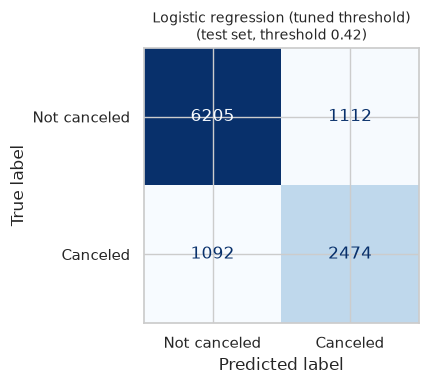

In [17]:
lr_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=1e6))  # ~unpenalised, same as statsmodels
print("Logistic regression, default threshold 0.50")
evaluate("Logistic regression (0.50)", lr_model, lr_cols, tune_threshold=False)
print("\nLogistic regression, threshold tuned on training folds")
lr = evaluate("Logistic regression (tuned threshold)", lr_model, lr_cols)

## 8. Decision trees: default, pre-pruned, post-pruned

🔍 **What we found:** A tree with no limits keeps splitting until it memorises the training data.  
💡 **Why it matters:** A memorised tree looks perfect on training rows and worse on new ones. The original analysis also picked the pruning strength by looking at the **test** F1, which leaks the test set into the model choice.  
🎯 **What we're doing now:** We show the overfit default tree. Then we choose both kinds of pruning with **5-fold cross-validation on the training set only**, so the test set is used exactly once, at the end.

threshold               0.500
CV F1 (train folds)     0.785
train F1                0.991
test precision          0.789
test recall             0.785
test F1                 0.787
test ROC-AUC            0.844
test F1 (unseen rows)   0.651


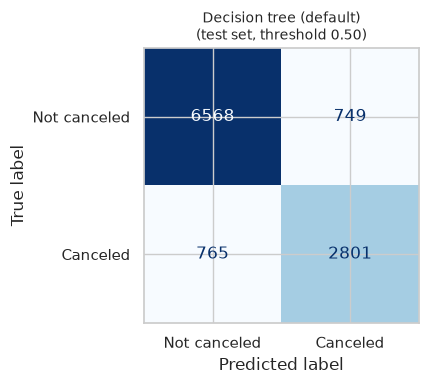


depth 36, 2,856 leaves


In [18]:
default_tree = evaluate("Decision tree (default)", DecisionTreeClassifier(random_state=RANDOM_STATE), tree_cols, tune_threshold=False)
print(f"\ndepth {default_tree.get_depth()}, {default_tree.get_n_leaves():,} leaves")

Best pre-pruning settings (by CV F1): {'class_weight': 'balanced', 'max_depth': 16, 'min_samples_leaf': 1} CV F1 = 0.801



threshold               0.621
CV F1 (train folds)     0.806
train F1                0.898
test precision          0.789
test recall             0.818
test F1                 0.803
test ROC-AUC            0.903
test F1 (unseen rows)   0.699


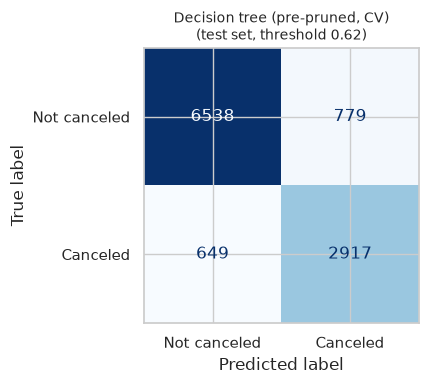


depth 16, 1,314 leaves


In [19]:
pre_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {"max_depth": [5, 8, 12, 16, 20, 25], "min_samples_leaf": [1, 3, 10, 25], "class_weight": [None, "balanced"]},
    scoring="f1", cv=CV, n_jobs=-1,
).fit(X_train[tree_cols], y_train)
print("Best pre-pruning settings (by CV F1):", pre_search.best_params_, f"CV F1 = {pre_search.best_score_:.3f}\n")
pre_tree = evaluate("Decision tree (pre-pruned, CV)", pre_search.best_estimator_, tree_cols)
print(f"\ndepth {pre_tree.get_depth()}, {pre_tree.get_n_leaves():,} leaves")

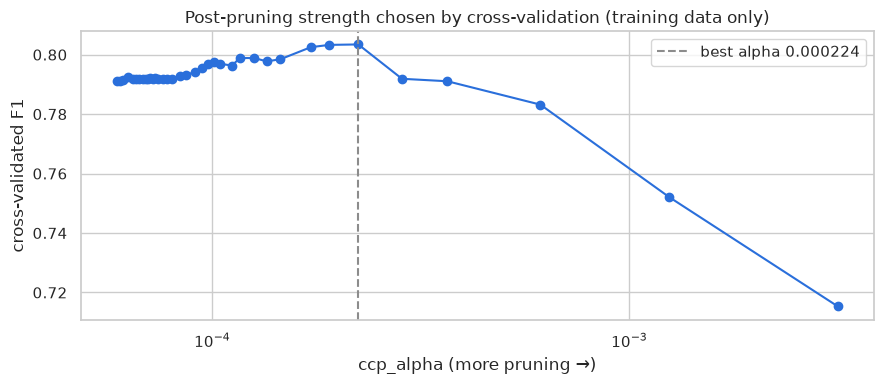

threshold               0.404
CV F1 (train folds)     0.805
train F1                0.820
test precision          0.808
test recall             0.792
test F1                 0.800
test ROC-AUC            0.926
test F1 (unseen rows)   0.719


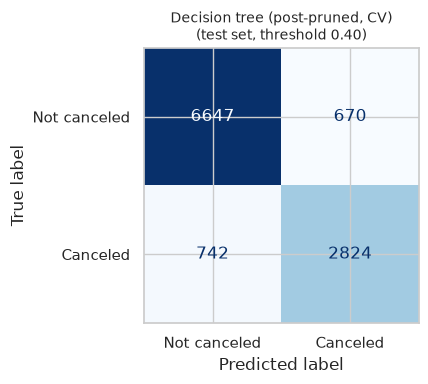


depth 14, 137 leaves


In [20]:
path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train[tree_cols], y_train)
alphas = np.unique(np.quantile(path.ccp_alphas[:-1], np.linspace(0.5, 0.995, 40)))  # 40 candidates, not all ~1,400
cv_f1 = [cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=a), X_train[tree_cols], y_train,
                         cv=CV, scoring="f1", n_jobs=-1).mean() for a in alphas]
best_alpha = alphas[int(np.argmax(cv_f1))]

plt.figure(figsize=(9, 4))
plt.semilogx(alphas, cv_f1, "o-", color=BLUE)
plt.axvline(best_alpha, color=GREY, ls="--", label=f"best alpha {best_alpha:.6f}")
plt.xlabel("ccp_alpha (more pruning →)"); plt.ylabel("cross-validated F1"); plt.legend()
plt.title("Post-pruning strength chosen by cross-validation (training data only)")
plt.tight_layout(); plt.show()

post_tree = evaluate("Decision tree (post-pruned, CV)", DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=best_alpha), tree_cols)
print(f"\ndepth {post_tree.get_depth()}, {post_tree.get_n_leaves():,} leaves")

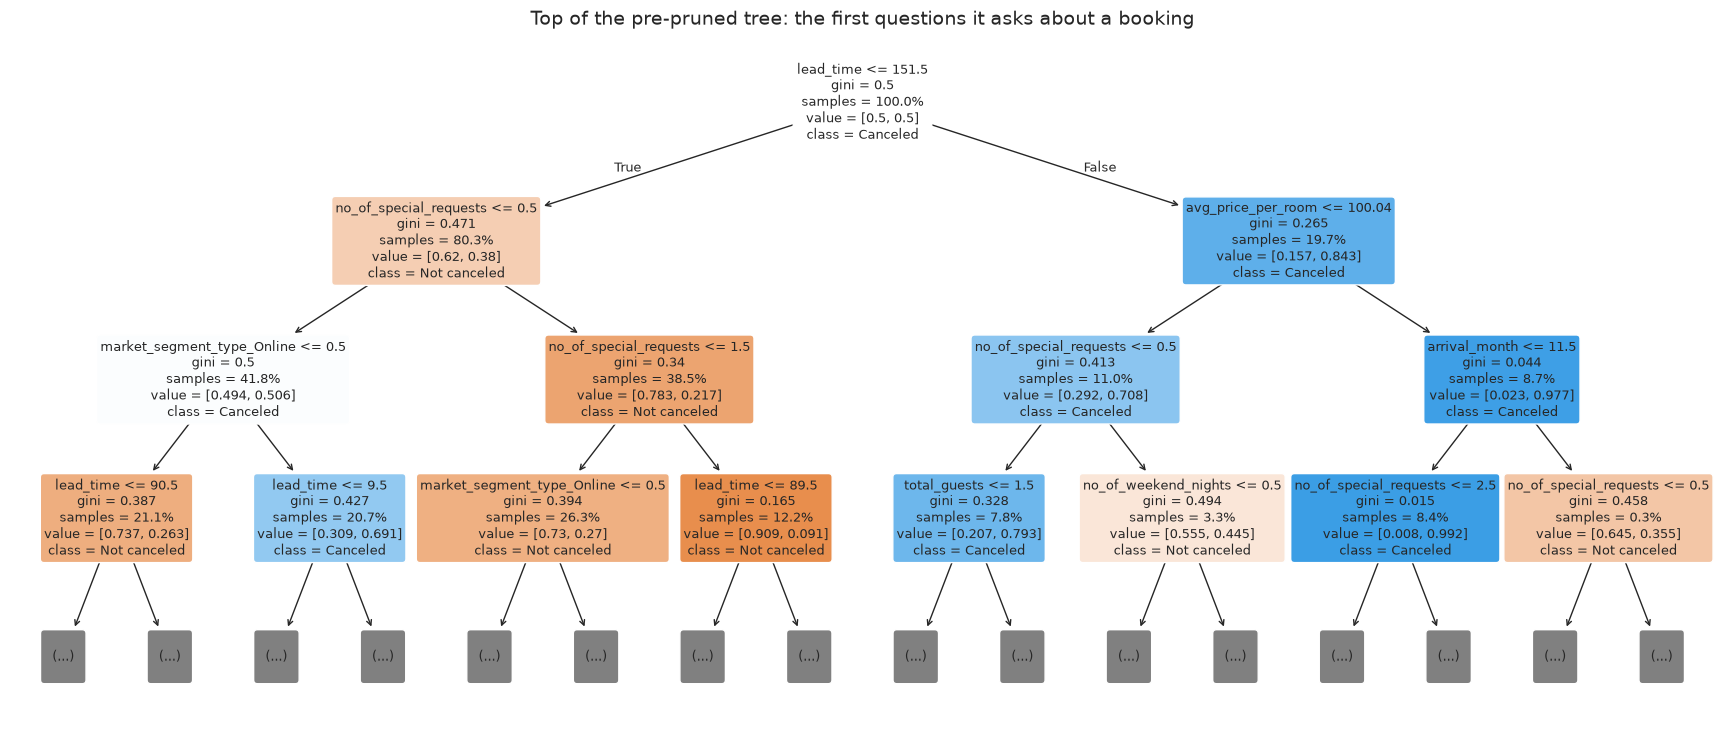

In [21]:
plt.figure(figsize=(22, 9))
plot_tree(pre_tree, feature_names=tree_cols, class_names=["Not canceled", "Canceled"], filled=True, rounded=True,
          max_depth=3, fontsize=9, proportion=True)
plt.title("Top of the pre-pruned tree: the first questions it asks about a booking", fontsize=14)
plt.show()

## 9. Ensembles: random forest and gradient boosting

🔍 **What we found:** A single tree is easy to read but unstable: a small change in the data can change it a lot.  
💡 **Why it matters:** Averaging many trees (random forest) or adding them step by step (gradient boosting) usually predicts better. This is what the AutoML Explorer picks for data of this size.  
🎯 **What we're doing now:** We tune both lightly with cross-validation on the training set, and tune the threshold the same way.

Random forest settings: {'max_features': 0.5, 'min_samples_leaf': 1} CV F1 = 0.833



threshold               0.473
CV F1 (train folds)     0.843
train F1                0.991
test precision          0.873
test recall             0.817
test F1                 0.844
test ROC-AUC            0.954
test F1 (unseen rows)   0.744


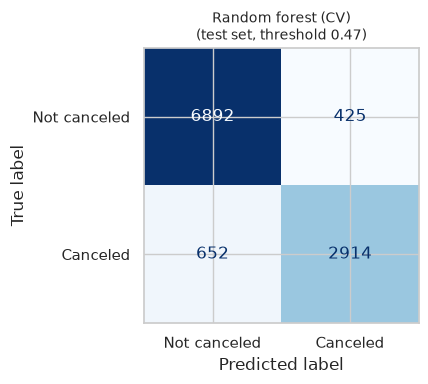

In [22]:
rf_search = GridSearchCV(
    RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    {"min_samples_leaf": [1, 3], "max_features": ["sqrt", 0.5]}, scoring="f1", cv=3,
).fit(X_train[tree_cols], y_train)
print("Random forest settings:", rf_search.best_params_, f"CV F1 = {rf_search.best_score_:.3f}\n")
rf = evaluate("Random forest (CV)", rf_search.best_estimator_, tree_cols)

Gradient boosting settings: {'learning_rate': 0.05, 'max_leaf_nodes': 63} CV F1 = 0.826



threshold               0.419
CV F1 (train folds)     0.834
train F1                0.922
test precision          0.839
test recall             0.829
test F1                 0.834
test ROC-AUC            0.952
test F1 (unseen rows)   0.744


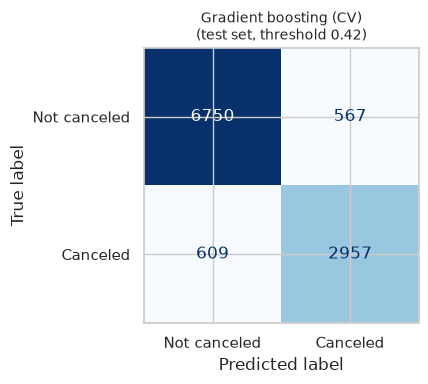

In [23]:
hgb_search = GridSearchCV(
    HistGradientBoostingClassifier(max_iter=400, random_state=RANDOM_STATE),
    {"learning_rate": [0.05, 0.1], "max_leaf_nodes": [31, 63]}, scoring="f1", cv=3,
).fit(X_train[tree_cols], y_train)
print("Gradient boosting settings:", hgb_search.best_params_, f"CV F1 = {hgb_search.best_score_:.3f}\n")
hgb = evaluate("Gradient boosting (CV)", hgb_search.best_estimator_, tree_cols)

## 10. Model comparison and final choice

🔍 **What we found:** We now have six models, each scored the same way.  
💡 **Why it matters:** If we picked the model with the best *test* score, the test set would stop being an honest check.  
🎯 **What we're doing now:** We choose the final model by **cross-validated F1 on the training folds**, then read its test scores. The 'unseen rows' column shows performance on bookings with no twin in training.

,threshold,CV F1 (train folds),train F1,test precision,test recall,test F1,test ROC-AUC,test F1 (unseen rows)
model,,,,,,,,
Logistic regression (0.50),0.500,0.682,0.682,0.733,0.626,0.675,0.861,0.623
Logistic regression (tuned threshold),0.421,0.700,0.699,0.690,0.694,0.692,0.861,0.642
Decision tree (default),0.500,0.785,0.991,0.789,0.785,0.787,0.844,0.651
"Decision tree (pre-pruned, CV)",0.621,0.806,0.898,0.789,0.818,0.803,0.903,0.699
"Decision tree (post-pruned, CV)",0.404,0.805,0.820,0.808,0.792,0.800,0.926,0.719
Random forest (CV),0.473,0.843,0.991,0.873,0.817,0.844,0.954,0.744
Gradient boosting (CV),0.419,0.834,0.922,0.839,0.829,0.834,0.952,0.744


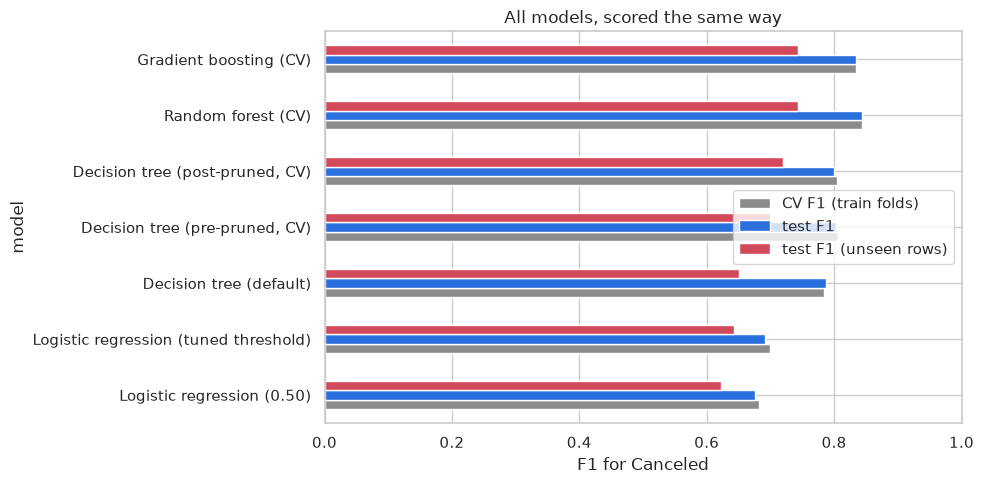

**Final model: Random forest (CV)** (highest cross-validated F1)
- On the test set it catches **82%** of cancellations (recall). When it flags a booking, it is right
  **87%** of the time (precision). F1 = **0.844** and ROC-AUC = 0.954.
- On **unseen** test rows (no identical twin in training) F1 is **0.744**. Expect roughly this on
  genuinely new bookings.
- Logistic regression reaches F1 0.692. It is weaker, but every
  effect is a readable odds ratio, so it is the model to *explain* the drivers with.
- For reference, the original analysis reported F1 0.808 for its best tree. That number was optimistic, because the pruning
  strength had been picked on the test set itself.


In [24]:
comparison = pd.DataFrame(results).set_index("model")
display(comparison.style.format("{:.3f}").background_gradient(cmap="Blues", subset=["CV F1 (train folds)", "test F1"]))

final_name = comparison["CV F1 (train folds)"].idxmax()
final_model = {"Random forest (CV)": rf, "Gradient boosting (CV)": hgb, "Decision tree (post-pruned, CV)": post_tree,
               "Decision tree (pre-pruned, CV)": pre_tree, "Logistic regression (tuned threshold)": lr,
               "Decision tree (default)": default_tree, "Logistic regression (0.50)": lr}[final_name]
final_cols = lr_cols if final_name.startswith("Logistic") else tree_cols
final = comparison.loc[final_name]

ax = comparison[["CV F1 (train folds)", "test F1", "test F1 (unseen rows)"]].plot.barh(figsize=(10, 5), color=[GREY, BLUE, RED])
ax.set_xlim(0, 1); ax.set_xlabel("F1 for Canceled"); ax.set_title("All models, scored the same way")
plt.tight_layout(); plt.show()

orig_best = 0.808  # original notebook's best: post-pruned tree, alpha chosen on the test set
say(f"""**Final model: {final_name}** (highest cross-validated F1)
- On the test set it catches **{final['test recall']:.0%}** of cancellations (recall). When it flags a booking, it is right
  **{final['test precision']:.0%}** of the time (precision). F1 = **{final['test F1']:.3f}** and ROC-AUC = {final['test ROC-AUC']:.3f}.
- On **unseen** test rows (no identical twin in training) F1 is **{final['test F1 (unseen rows)']:.3f}**. Expect roughly this on
  genuinely new bookings.
- Logistic regression reaches F1 {comparison.loc['Logistic regression (tuned threshold)', 'test F1']:.3f}. It is weaker, but every
  effect is a readable odds ratio, so it is the model to *explain* the drivers with.
- For reference, the original analysis reported F1 {orig_best} for its best tree. That number was optimistic, because the pruning
  strength had been picked on the test set itself.
""")

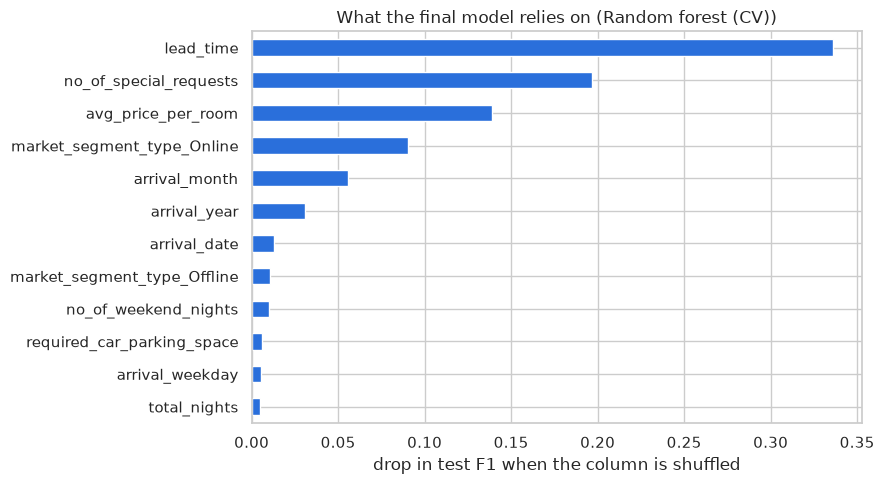

**Top 5 features of the final model:** `lead_time`, `no_of_special_requests`, `avg_price_per_room`, `market_segment_type_Online`, `arrival_month`. These match the drivers found in section 4, which is a good sign the model learned real patterns.

In [25]:
check = X_test.sample(3000, random_state=RANDOM_STATE)
imp = permutation_importance(final_model, check[final_cols], y_test.loc[check.index], scoring="f1", n_repeats=5,
                             random_state=RANDOM_STATE, n_jobs=-1)
importance = pd.Series(imp.importances_mean, index=final_cols).sort_values(ascending=False)
importance.head(12).sort_values().plot.barh(color=BLUE, figsize=(9, 5))
plt.xlabel("drop in test F1 when the column is shuffled"); plt.title(f"What the final model relies on ({final_name})")
plt.tight_layout(); plt.show()
say("**Top 5 features of the final model:** " + ", ".join(f"`{c}`" for c in importance.index[:5]) +
    ". These match the drivers found in section 4, which is a good sign the model learned real patterns.")

## 11. Business insights and recommendations

🔍 **What we found:** We know which bookings cancel, how strongly each factor matters, and how well we can predict it.  
💡 **Why it matters:** Insights only create value when they change a decision: a policy, a price, a message to a guest.  
🎯 **What we're doing now:** We turn each finding into an action, using the numbers computed above.

In [26]:
lead_hi, lead_lo = rate("lead time (days)", "251+"), rate("lead time (days)", "0-30")
req0, req2 = rate("special requests", 0), rate("special requests", 2)
online, corporate = rate("market segment", "Online"), rate("market segment", "Corporate")
months_hi = month["rate"].nlargest(3)
say(f"""### Key insights
1. **{overall:.1%} of bookings are cancelled.** About one in three booked rooms is at risk.
2. **Lead time is the biggest driver.** {lead_lo:.0%} of bookings made within 30 days are cancelled, against {lead_hi:.0%} for
   bookings made more than 250 days ahead.
3. **Special requests mean commitment.** {req0:.0%} cancel with no request, and only {req2:.0%} with two.
4. **Online is the riskiest channel** ({online:.1%}), against {corporate:.1%} for corporate bookings. Complementary stays never cancel.
5. **Repeat guests almost never cancel** ({rate('repeated guest', 1):.1%}), but they are only {share('repeated_guest', 1):.1%} of bookings.
6. **Seasonality**: cancellations peak for {", ".join(MONTH[m] for m in months_hi.index)} arrivals, and are lowest for {", ".join(MONTH[m] for m in month["rate"].nsmallest(2).index)}.
7. **Prediction works.** The final model catches {final['test recall']:.0%} of cancellations with {final['test precision']:.0%} precision.

### Recommendations
| # | Action | Based on | Priority |
|---|---|---|---|
| 1 | **Re-confirm long-lead bookings** by email/SMS at 90, 30 and 7 days before arrival, starting with bookings made more than 150 days ahead | lead time: {lead_hi:.0%} cancel | High |
| 2 | **Differentiated cancellation policies**: a deposit or non-refundable option for high-risk profiles (online, long lead, no requests); flexible terms for corporate and repeat guests | segment and lead-time rates | High |
| 3 | **Encourage special requests** at booking (view, floor, extras). Each request is a signal of commitment | {req0:.0%} → {req2:.0%} | High |
| 4 | **Score every new booking with the model** and send the top-risk ones to targeted re-confirmation and controlled overbooking | F1 {final['test F1']:.2f}, recall {final['test recall']:.0%} | Medium |
| 5 | **Grow the loyalty programme**: repeat guests are the most reliable customers but only {share('repeated_guest', 1):.1%} of bookings | {rate('repeated guest', 1):.1%} cancel | Medium |
| 6 | **Seasonal planning**: stricter terms and overbooking buffers in peak-cancellation months ({", ".join(MONTH[m] for m in months_hi.index)}); full staffing in {" and ".join(MONTH[m] for m in month["rate"].nsmallest(2).index)} | monthly rates | Medium |
| 7 | **Review the online booking flow**: add a small deposit for online bookings made far ahead, and send pre-arrival engagement emails | online {online:.1%} | Medium |

### Choosing the alert threshold is a business decision
A **missed cancellation** (false negative) leaves a room empty. A **false alarm** (false positive) costs a reminder email or a
slightly risky overbooking. Missing a cancellation is usually far more expensive, so the hotel can lower the threshold further
to catch more cancellations, trading some precision. The precision/recall numbers above show what each choice costs.
""")

### Key insights
1. **32.8% of bookings are cancelled.** About one in three booked rooms is at risk.
2. **Lead time is the biggest driver.** 14% of bookings made within 30 days are cancelled, against 77% for
   bookings made more than 250 days ahead.
3. **Special requests mean commitment.** 43% cancel with no request, and only 15% with two.
4. **Online is the riskiest channel** (36.5%), against 10.9% for corporate bookings. Complementary stays never cancel.
5. **Repeat guests almost never cancel** (1.7%), but they are only 2.6% of bookings.
6. **Seasonality**: cancellations peak for July, June, August arrivals, and are lowest for January, December.
7. **Prediction works.** The final model catches 82% of cancellations with 87% precision.

### Recommendations
| # | Action | Based on | Priority |
|---|---|---|---|
| 1 | **Re-confirm long-lead bookings** by email/SMS at 90, 30 and 7 days before arrival, starting with bookings made more than 150 days ahead | lead time: 77% cancel | High |
| 2 | **Differentiated cancellation policies**: a deposit or non-refundable option for high-risk profiles (online, long lead, no requests); flexible terms for corporate and repeat guests | segment and lead-time rates | High |
| 3 | **Encourage special requests** at booking (view, floor, extras). Each request is a signal of commitment | 43% → 15% | High |
| 4 | **Score every new booking with the model** and send the top-risk ones to targeted re-confirmation and controlled overbooking | F1 0.84, recall 82% | Medium |
| 5 | **Grow the loyalty programme**: repeat guests are the most reliable customers but only 2.6% of bookings | 1.7% cancel | Medium |
| 6 | **Seasonal planning**: stricter terms and overbooking buffers in peak-cancellation months (July, June, August); full staffing in January and December | monthly rates | Medium |
| 7 | **Review the online booking flow**: add a small deposit for online bookings made far ahead, and send pre-arrival engagement emails | online 36.5% | Medium |

### Choosing the alert threshold is a business decision
A **missed cancellation** (false negative) leaves a room empty. A **false alarm** (false positive) costs a reminder email or a
slightly risky overbooking. Missing a cancellation is usually far more expensive, so the hotel can lower the threshold further
to catch more cancellations, trading some precision. The precision/recall numbers above show what each choice costs.


## Appendix: what changed compared with the earlier versions

| Topic | Hand-made notebook | AutoML (no target chosen) | This notebook |
|---|---|---|---|
| Task | ✅ classification | ❌ clustering, with `booking_status` used as an input | ✅ classification |
| Duplicates | "0", hidden by `Booking_ID` | not checked | 10,275 look-alikes found; scored on unseen rows too |
| Impossible dates | not checked | not checked | 37 × 29 Feb 2018 fixed; weekday added |
| Logistic regression | did not converge (totals + perfect separation) | – | converges; VIF < 5; odds ratios explained |
| Threshold | chosen on training data | – | chosen on out-of-fold training predictions |
| Tree pruning | alpha picked on **test** F1 (leakage) | – | chosen by 5-fold CV on training data only |
| Models | LR, 3 trees | KMeans | LR, 3 trees, random forest, gradient boosting, baseline |
| Explanations | print banners | found / why / doing | found / why / doing, plus observations computed from the data |
| Insight text | some numbers wrong (e.g. "Online ~40%", "Sep/Oct highest") | – | every number printed from the data |